# Neurons and Layers

## Goals
In this lab, I will explore the inner workings of neurons and layers, drawing parallels to the regression and logistic models from Course 1, and get introduced to Tensorflow.

## Packages
Tensorflow is a machine learning package developed by Google. Keras is a framework that provides a simple, layer-centric interface to Tensorflow, and this course uses the Keras interface.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf  

In [3]:
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras import Sequential

In [4]:
X_train = np.array([[1.0], [2.0]], dtype=np.float32)  #dtype float32 for gpu computation
Y_train = np.array([[300.0], [500.0]], dtype=np.float32)

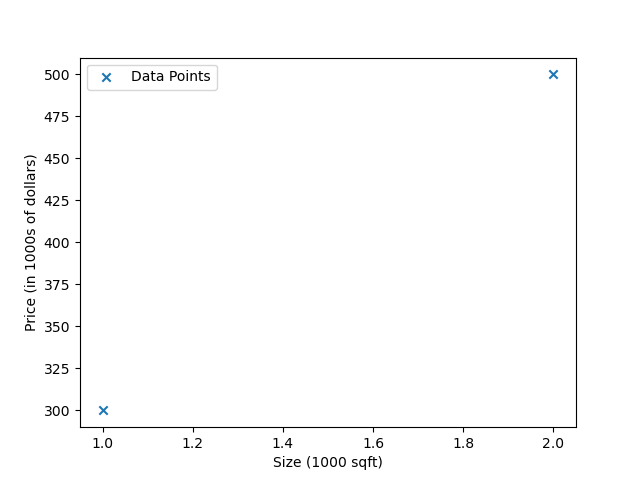

In [5]:
fig, ax = plt.subplots(1, 1)

ax.scatter(X_train, Y_train, marker='x', label="Data Points")

ax.set_ylabel('Price (in 1000s of dollars)')
ax.set_xlabel('Size (1000 sqft)')
ax.legend()

plt.savefig("house_price_training_data.png")
plt.close()

from IPython.display import Image
Image("house_price_training_data.png")

### Linear Regression Model
A neuron without an activation function computes the same function as linear regression: f(x) = wx + b.

In [6]:
linear_layer = Dense(units=1,activation='linear')

In [7]:
linear_layer.get_weights() #fucntion to get value of weights

[]

In [8]:
# Grab the first training example and reshape it to 2D (1 sample, 1 feature)
# Keras layers always expect a 2D matrix as input, even for a single number!
a1 = linear_layer(X_train[0].reshape(1,1))   

print(a1)

tf.Tensor([[1.4619964]], shape=(1, 1), dtype=float32)


In [9]:
linear_layer.get_weights()

[array([[1.4619964]], dtype=float32), array([0.], dtype=float32)]

In [10]:
set_w = np.array([[200]])  #should be matrix
set_b = np.array([100])    #should be a single array 

# set_weights takes a list of numpy arrays: [w_array, b_array]
linear_layer.set_weights([set_w,set_b])
print(linear_layer.get_weights())

[array([[200.]], dtype=float32), array([100.], dtype=float32)]


In [11]:
a1 = linear_layer(X_train[0].reshape(1,1))   #tensorflow prediction
print(a1)

alin = np.dot(set_w,X_train[0].reshape(1,1))+set_b  #manual prediction
print(alin)

tf.Tensor([[300.]], shape=(1, 1), dtype=float32)
[[300.]]


In [12]:
prediction_tf = linear_layer(X_train)
prediction_np = np.dot(X_train, set_w) + set_b

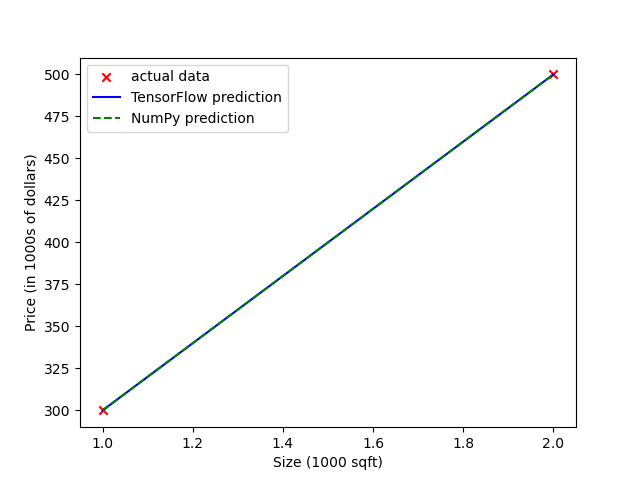

In [13]:
fig,ax = plt.subplots(1,1)
ax.scatter(X_train,Y_train,marker='x',c = 'red',label='actual data')
ax.plot(X_train,prediction_tf,c='blue',label="TensorFlow prediction")
ax.plot(X_train, prediction_np, c='green', linestyle='--', label="NumPy prediction")
ax.set_ylabel('Price (in 1000s of dollars)')
ax.set_xlabel('Size (1000 sqft)')
ax.legend()

plt.savefig("house_price_prediction.png")
plt.close()
from IPython.display import Image
Image("house_price_prediction.png")

## Neuron with sigmoid activation
A neuron with sigmoid activation computes the same function as logistic regression: f(x) = sigmoid(wx + b).

In [14]:
X_train = np.array([0., 1, 2, 3, 4, 5], dtype=np.float32).reshape(-1,1)
Y_train = np.array([0,  0, 0, 1, 1, 1], dtype=np.float32).reshape(-1,1)

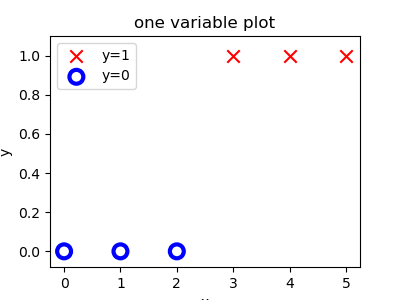

In [15]:
pos = Y_train == 1
neg = Y_train == 0

fig,ax = plt.subplots(1,1,figsize=(4,3))
ax.scatter(X_train[pos], Y_train[pos], marker='x', s=80, c='red', label="y=1")
ax.scatter(X_train[neg], Y_train[neg], marker='o', s=100, label="y=0", facecolors='none', edgecolors='blue', lw=3)

ax.set_ylim(-0.08,1.1)
ax.set_ylabel('y')
ax.set_xlabel('x')
ax.set_title('one variable plot')
ax.legend()

plt.savefig("logistic_neuron_data.png")
plt.close()
from IPython.display import Image
Image("logistic_neuron_data.png")

In [17]:
model = Sequential(  #sequential for sequense and take array of layers
    [
        Dense(1,input_dim=1,activation='sigmoid',name='L1')           #input_dim  = 1 mean expect 1 input_feature and name for layer name 
    ]
)

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ L1 (Dense)                           │ (None, 1)                   │               2 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
logistic_layer = model.get_layer('L1')  #getting specific layer in model
w,b = logistic_layer.get_weights()     #getting weights values
print(w,b)

[[0.8657938]] [0.]


In [21]:
set_w = np.array([[2]])
set_b = np.array([-4.5])
logistic_layer.set_weights([set_w, set_b])  #setting weights values
print(logistic_layer.get_weights())

[array([[2.]], dtype=float32), array([-4.5], dtype=float32)]


In [23]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [24]:
a1 = model.predict(X_train[0].reshape(1,1))
print(a1)
alog = alog = sigmoid(np.dot(set_w,X_train[0].reshape(1,1)) + set_b)
print(alog)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[[0.01098694]]
[[0.01098694]]


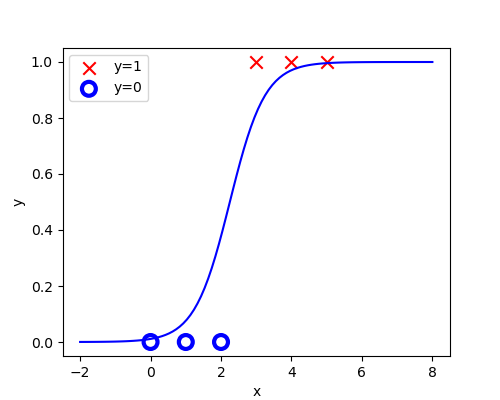

In [25]:
x0 = np.linspace(-2, 8, 100).reshape(-1,1)
y0 = sigmoid(np.dot(x0, set_w) + set_b)

fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(x0, y0, c='blue')
ax.scatter(X_train[pos], Y_train[pos], marker='x', s=80, c='red', label="y=1")
ax.scatter(X_train[neg], Y_train[neg], marker='o', s=100, facecolors='none', edgecolors='blue', lw=3, label="y=0")
ax.set_ylabel('y')
ax.set_xlabel('x')
ax.legend()
plt.savefig("logistic_neuron_fit.png")
plt.close()
from IPython.display import Image
Image("logistic_neuron_fit.png")

### Summary
This lab built neurons in TensorFlow/Keras mirroring Course 1's linear and logistic regression models, confirming both produce identical results to the hand-built NumPy versions.